In [28]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.transform import rotate
from skimage.transform import (hough_line, hough_line_peaks)
from scipy.stats import mode
from skimage import io
from skimage.filters import threshold_otsu, sobel
from matplotlib import cm
import cv2
from skimage.feature import canny

In [36]:
def enhanceText(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # CLAHE (adaptive contrast boost)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    contrast = clahe.apply(gray)

    # Adaptive threshold (handles uneven lighting)
    binary = cv2.adaptiveThreshold(
        contrast,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,   # block size
        10    # constant
    )

    return binary

In [33]:
def cropToContent(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Threshold to get content mask
    _, thresh = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)

    # Find coordinates of non-zero pixels
    coords = cv2.findNonZero(thresh)

    if coords is None:
        return image  # nothing detected, return as is

    x, y, w, h = cv2.boundingRect(coords)

    cropped = image[y:y+h, x:x+w]

    return cropped

In [40]:
def isSkewed(angle, threshold=1.0):
    return abs(angle) > threshold

def binarizeImage(RGB_image):
  # Handle RGBA → RGB
  if RGB_image.shape[-1] == 4:
      RGB_image = RGB_image[:, :, :3]

  image = rgb2gray(RGB_image)
  threshold = threshold_otsu(image)
  bina_image = image < threshold

  return bina_image

def findEdges(bina_image):

  image_edges = canny(bina_image)

  plt.imshow(image_edges, cmap='gray')
  plt.axis('off')

  return image_edges

def findTiltAngle(image_edges):

  h, theta, d = hough_line(image_edges)
  accum, angles, dists = hough_line_peaks(
    h, theta, d,
    threshold=0.3 * np.max(h),   # lower threshold
    num_peaks=20                 # allow more lines
)
  if len(angles) == 0:
      return 0

  angle = np.median(np.rad2deg(angles))  # better than mode
  print("ANGLE---", angle)

  if angle < 0:
      return angle + 90
  else:
      return angle - 90

  # Plot Image and Lines
  fig, ax = plt.subplots()


  ax.imshow(image_edges, cmap='gray')

  origin = np.array((0, image_edges.shape[1]))

  for _, angle, dist in zip(*hough_line_peaks(h, theta, d)):

    y0, y1 = (dist - origin * np.cos(angle)) / np.sin(angle)
    ax.plot(origin, (y0, y1), '-r')

  ax.set_xlim(origin)
  ax.set_ylim((image_edges.shape[0], 0))
  ax.set_axis_off()
  ax.set_title('Detected lines')

  plt.savefig('/content/drive/My Drive/hough_lines.png')

  plt.show()

  return r_angle


def rotateImage(RGB_image, angle):

    (h, w) = RGB_image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        RGB_image,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,   # better quality
        borderMode=cv2.BORDER_REPLICATE
        # borderMode=cv2.BORDER_CONSTANT  # then crop later
    )
    # 🔥 crop after rotation
    cropped = cropToContent(rotated)
    enhanced = enhanceText(cropped)

    plt.imshow(enhanced, cmap='gray')
    plt.axis('off')
    plt.title('Fixed Image')
    plt.savefig('/content/drive/My Drive/fixed_image.png', dpi=300)
    plt.show()

    return rotated

def generalPipeline():

  img = '/content/drive/My Drive/11.jpg'

  image = io.imread(img)

  bina_image = binarizeImage(image)
  image_edges = findEdges(bina_image)
  angle = findTiltAngle(image_edges)

  print("Detected angle:", angle)

  if isSkewed(angle):
      print("Image is skewed → correcting")
      rotateImage(image, angle)
  else:
      print("Image is already aligned")

ANGLE--- -88.0
Detected angle: 2.0
Image is skewed → correcting


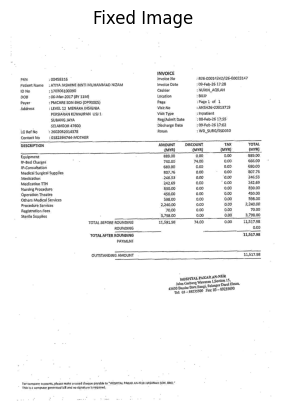

In [41]:
generalPipeline()